# Posterior Diagnostics Tutorial

This notebook walks through all the classes and functions in `psiphy.plotting.diagnostics`,
using the built-in toy models to generate realistic posteriors.

## What is covered

| Class / function | Description |
|---|---|
| `SampledDistribution` | Posterior from MCMC / IS weighted samples |
| `GriddedProbabilities` | Posterior on a regular N-D grid |
| `PosteriorComparison` | Side-by-side comparison: boxplot, forest, metrics table |
| `plot_triangle` | Corner / triangle plot (multi-backend) |
| `print_chain_stats` | Weighted mean, std, and credible intervals |

### Diagnostic metrics available on every distribution

| Method | What it measures |
|---|---|
| `credible_intervals(levels)` | Equal-tailed marginal CIs from the empirical CDF |
| `z_scores()` | Per-parameter `|mean − truth| / sigma` |
| `bias()` | Per-parameter `median − truth` |
| `pit()` | Probability Integral Transform — `CDF(truth)` per parameter |
| `mahalanobis()` | Multivariate distance from posterior mean to truth |
| `kl_divergence(other)` | Per-parameter KL divergence between two posteriors |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from psiphy.mcmc import (
    UniformPrior,
    importance_sampling,
    SMC,
)
from psiphy.toy_models import GaussianSignal, NoisyLine

from psiphy.plotting.diagnostics import (
    SampledDistribution,
    GriddedProbabilities,
    PosteriorComparison,
    plot_triangle,
    print_chain_stats,
)

np.random.seed(42)

---
## 1  Generate posteriors from toy models

We use `GaussianSignal` (2 parameters: mean $\mu$, std $\sigma$) and `NoisyLine`
(2 parameters: slope $m$, intercept $b$) as test beds.
Posteriors are approximated with **IS** (tight proposal) and **SMC** (broad prior).

In [2]:
# ── GaussianSignal setup ──────────────────────────────────────────────────────
gs = GaussianSignal(N=60)
theta_true_gs = np.array([1.5, 0.8])   # [mean, sigma]
x_obs = gs.simulate(theta_true_gs)

prior_gs = UniformPrior([(0.0, 3.0), (0.2, 2.0)])
log_post_gs = lambda t: gs.log_prob(t, x_obs) + prior_gs.log_prob(t)

# IS posterior (tight proposal → good ESS)
prop_is = prior_gs.sample(8000)
s_is, w_is = importance_sampling(log_post_gs, prop_is)

# SMC posterior (broad prior)
prior_broad = UniformPrior([(-2, 5), (0.1, 4)])
s_smc, w_smc = SMC(
    lambda t: gs.log_prob(t, x_obs),
    prior_broad,
    n_particles=2000,
    n_steps=12,
    verbose=False,
)

print(f'IS   particles={len(s_is)}, true={theta_true_gs}')
print(f'SMC  particles={len(s_smc)}, true={theta_true_gs}')

IS   particles=8000, true=[1.5 0.8]
SMC  particles=2000, true=[1.5 0.8]


In [3]:
# ── NoisyLine setup ───────────────────────────────────────────────────────────
nl = NoisyLine(Nx=50, noise_sigma=0.4)
theta_true_nl = np.array([-0.8, 5.0])   # [slope, intercept]
y_obs = nl.simulate(theta_true_nl)

prior_nl = UniformPrior([(-3.0, 3.0), (2.0, 8.0)])
log_post_nl = lambda t: nl.log_prob(t, y_obs) + prior_nl.log_prob(t)

prop_nl = prior_nl.sample(8000)
s_nl, w_nl = importance_sampling(log_post_nl, prop_nl)

print(f'NoisyLine IS  true={theta_true_nl}')

NoisyLine IS  true=[-0.8  5. ]


---
## 2  `SampledDistribution`

`SampledDistribution` wraps weighted samples (e.g. from IS or MCMC) and provides
all diagnostic metrics through a common interface.

In [4]:
dist_is = SampledDistribution(
    s_is,
    weights=w_is,
    true_values=theta_true_gs,
    labels=[r'\mu', r'\sigma'],
)

dist_smc = SampledDistribution(
    s_smc,
    weights=w_smc,
    true_values=theta_true_gs,
    labels=[r'\mu', r'\sigma'],
)

print('n_params:', dist_is.n_params)

n_params: 2


### 2a  `print_stats` — mean, std, and credible intervals

In [5]:
print('── IS posterior ──────────────────────────────')
dist_is.print_stats(levels=(68, 95))

print()
print('── SMC posterior ─────────────────────────────')
dist_smc.print_stats(levels=(68, 95))

── IS posterior ──────────────────────────────
Parameter summary
  \mu:  mean = 1.3584,  std = 0.0956
    68% CI: [1.2735, 1.4594]
    95% CI: [1.1850, 1.5386]
  \sigma:  mean = 0.7453,  std = 0.0651
    68% CI: [0.6728, 0.8134]
    95% CI: [0.6025, 0.8785]

── SMC posterior ─────────────────────────────
Parameter summary
  \mu:  mean = 1.3736,  std = 0.0876
    68% CI: [1.2955, 1.4302]
    95% CI: [1.2117, 1.5856]
  \sigma:  mean = 0.7414,  std = 0.0779
    68% CI: [0.6543, 0.8302]
    95% CI: [0.6221, 0.9201]


### 2b  Scalar metrics

In [6]:
print('IS posterior metrics')
print('  z-scores      :', np.round(dist_is.z_scores(), 3))
print('  bias          :', np.round(dist_is.bias(), 3))
print('  PIT           :', np.round(dist_is.pit(), 3))
print('  Mahalanobis D :', round(dist_is.mahalanobis(), 3))

print()
print('SMC posterior metrics')
print('  z-scores      :', np.round(dist_smc.z_scores(), 3))
print('  bias          :', np.round(dist_smc.bias(), 3))
print('  PIT           :', np.round(dist_smc.pit(), 3))
print('  Mahalanobis D :', round(dist_smc.mahalanobis(), 3))

IS posterior metrics
  z-scores      : [1.481 0.841]
  bias          : [-0.149 -0.051]
  PIT           : [0.913 0.815]
  Mahalanobis D : 1.552

SMC posterior metrics
  z-scores      : [1.444 0.753]
  bias          : [-0.124 -0.063]
  PIT           : [0.928 0.72 ]
  Mahalanobis D : 1.762


### 2c  KL divergence between IS and SMC posteriors

In [7]:
kl = dist_is.kl_divergence(dist_smc)
labels = [r'$\mu$', r'$\sigma$']
for lbl, k in zip(labels, kl):
    print(f'  KL(IS || SMC)  {lbl} = {k:.4f}')

  KL(IS || SMC)  $\mu$ = 0.7429
  KL(IS || SMC)  $\sigma$ = 0.6496


---
## 3  `GriddedProbabilities`

`GriddedProbabilities` holds a posterior evaluated on a regular parameter grid.
Credible intervals are computed directly from 1-D marginals — efficient for large grids.

The optional `true_ranges` parameter enables `score()`, which measures how much posterior
mass falls inside a rectangular truth region (useful for challenge-style scoring).

In [8]:
# Build a 2-D log-posterior grid for GaussianSignal
n_grid = 80
mu_grid   = np.linspace(0.5,  2.5, n_grid)
sig_grid  = np.linspace(0.3,  1.5, n_grid)

MU, SIG = np.meshgrid(mu_grid, sig_grid, indexing='ij')
log_grid = np.vectorize(
    lambda mu, sig: gs.log_prob(np.array([mu, sig]), x_obs) + prior_gs.log_prob(np.array([mu, sig]))
)(MU, SIG)

prob_grid = np.exp(log_grid - log_grid.max())   # normalise for numerical stability

dist_grid = GriddedProbabilities(
    prob_grid,
    coords=[mu_grid, sig_grid],
    true_values=theta_true_gs,
    labels=[r'\mu', r'\sigma'],
    true_ranges=[[1.2, 1.8], [0.6, 1.0]],   # illustrative truth cube
)

print('Grid shape:', prob_grid.shape)
print('n_params  :', dist_grid.n_params)

Grid shape: (80, 80)
n_params  : 2


In [9]:
print('Grid posterior metrics')
print('  z-scores      :', np.round(dist_grid.z_scores(), 3))
print('  bias          :', np.round(dist_grid.bias(), 3))
print('  PIT           :', np.round(dist_grid.pit(), 3))
print('  Mahalanobis D :', round(dist_grid.mahalanobis(), 3))
print('  score         :', round(dist_grid.score(), 4))

Grid posterior metrics
  z-scores      : [1.282 0.813]
  bias          : [-0.136 -0.07 ]
  PIT           : [0.921 0.828]
  Mahalanobis D : 1.517
  score         : 0.9613


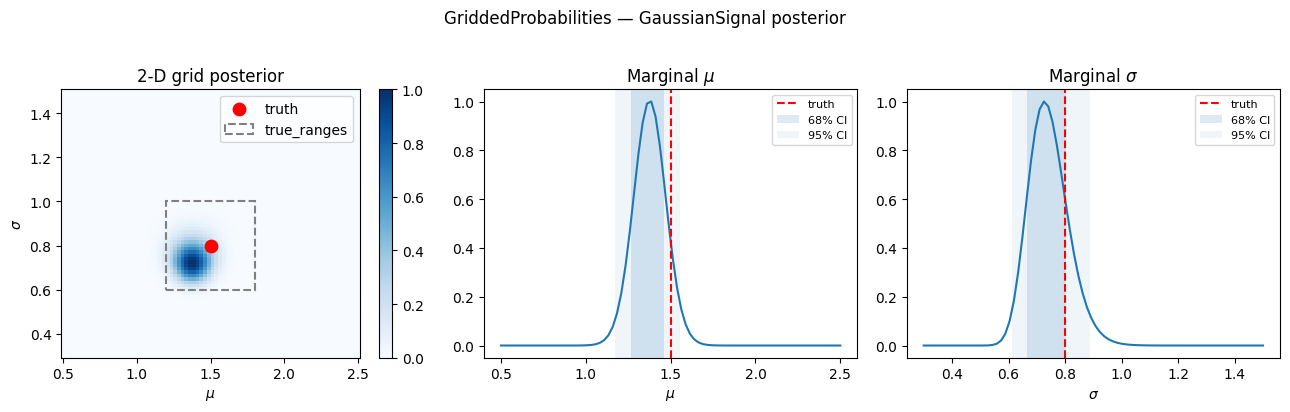

In [10]:
# Visualise the 2-D grid with marginals
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# 2-D posterior
im = axes[0].pcolormesh(mu_grid, sig_grid, prob_grid.T / prob_grid.max(),
                         cmap='Blues')
axes[0].scatter(*theta_true_gs, c='red', s=80, zorder=5, label='truth')
rect = plt.Rectangle((1.2, 0.6), 0.6, 0.4, fill=False, edgecolor='gray',
                       linestyle='--', lw=1.5, label='true_ranges')
axes[0].add_patch(rect)
axes[0].set(xlabel=r'$\mu$', ylabel=r'$\sigma$', title='2-D grid posterior')
axes[0].legend()
plt.colorbar(im, ax=axes[0])

# Marginal mu
marg_mu = prob_grid.sum(axis=1)
axes[1].plot(mu_grid, marg_mu / marg_mu.max())
axes[1].axvline(theta_true_gs[0], c='red', ls='--', label='truth')
ci_mu = dist_grid.credible_intervals()[0]
axes[1].axvspan(ci_mu['lo68'], ci_mu['hi68'], alpha=0.15, label='68% CI')
axes[1].axvspan(ci_mu['lo95'], ci_mu['hi95'], alpha=0.07, label='95% CI')
axes[1].set(xlabel=r'$\mu$', title=r'Marginal $\mu$')
axes[1].legend(fontsize=8)

# Marginal sigma
marg_sig = prob_grid.sum(axis=0)
axes[2].plot(sig_grid, marg_sig / marg_sig.max())
axes[2].axvline(theta_true_gs[1], c='red', ls='--', label='truth')
ci_sig = dist_grid.credible_intervals()[1]
axes[2].axvspan(ci_sig['lo68'], ci_sig['hi68'], alpha=0.15, label='68% CI')
axes[2].axvspan(ci_sig['lo95'], ci_sig['hi95'], alpha=0.07, label='95% CI')
axes[2].set(xlabel=r'$\sigma$', title=r'Marginal $\sigma$')
axes[2].legend(fontsize=8)

fig.suptitle('GriddedProbabilities — GaussianSignal posterior', y=1.02)
plt.tight_layout()
plt.show()

---
## 4  `PosteriorComparison` — side-by-side diagnostics

`PosteriorComparison` accepts any mix of `SampledDistribution` and `GriddedProbabilities`
objects and produces aligned comparison plots.

We compare three posteriors for the same `GaussianSignal` experiment:
1. **IS** — importance sampling with tight proposal
2. **SMC** — sequential Monte Carlo from a broad prior
3. **Grid** — full 2-D grid posterior evaluated analytically

In [11]:
# marker=True (default) → auto-assigns from the marker cycle
# color=None → auto-assigns from tab20 colour cycle
comp = PosteriorComparison()
comp.add(dist_is,   label='IS',   color='C0')
comp.add(dist_smc,  label='SMC',  color='C2')
comp.add(dist_grid, label='Grid', color='C3')

### 4a  Boxplot — box = 68% CI, whiskers = 95% CI, marker = median

`marker=True` (default) auto-assigns a symbol from the cycle. Pass `marker=None` to suppress it.

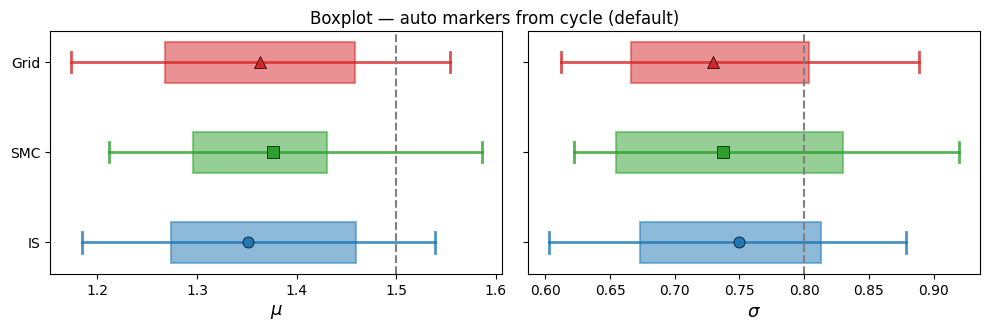

In [12]:
fig = comp.plot_boxplot(levels=(68, 95))
plt.suptitle('Boxplot — auto markers from cycle (default)', y=1.02)
plt.show()

### 4b  Forest plot — errorbar style

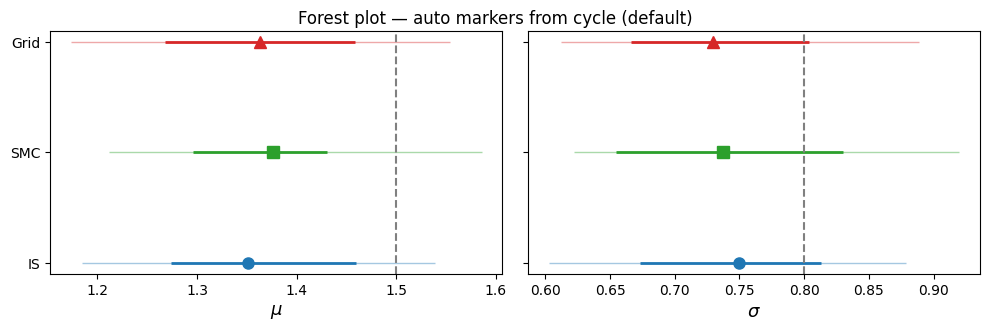

In [13]:
fig = comp.plot_forest(levels=(68, 95))
plt.suptitle('Forest plot — auto markers from cycle (default)', y=1.02)
plt.show()

### 4c  Per-entry styling: `marker`, `markersize`, `linewidth`

| `marker` value | Effect |
|---|---|
| `True` (default) | Auto-assign from marker cycle |
| `None` | No marker drawn (matplotlib convention) |
| `'o'`, `'s'`, `'^'`, … | Use that specific symbol |

`markersize` and `linewidth` per entry override the method-level defaults.

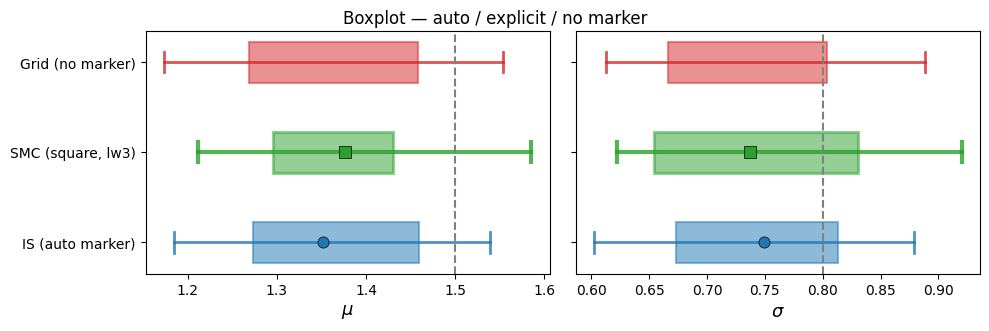

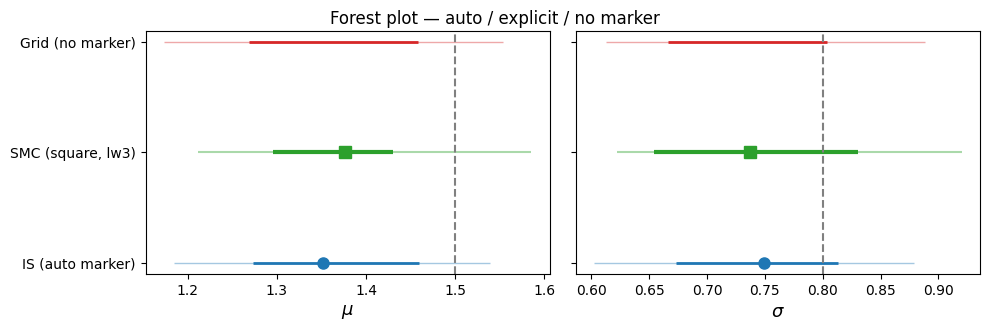

In [14]:
comp_styled = PosteriorComparison()
comp_styled.add(dist_is,   label='IS (auto marker)',  color='C0')                          # marker=True → cycle
comp_styled.add(dist_smc,  label='SMC (square, lw3)', color='C2', marker='s', linewidth=3)  # explicit marker
comp_styled.add(dist_grid, label='Grid (no marker)',  color='C3', marker=None)              # suppress marker

fig = comp_styled.plot_boxplot(levels=(68, 95))
plt.suptitle('Boxplot — auto / explicit / no marker', y=1.02)
plt.show()

fig = comp_styled.plot_forest(levels=(68, 95))
plt.suptitle('Forest plot — auto / explicit / no marker', y=1.02)
plt.show()

### 4d  Legend panel

Entries with `marker=None` appear as a solid coloured line; others show their marker symbol.

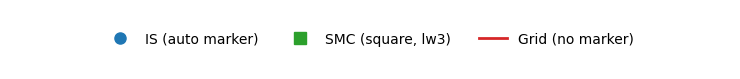

In [15]:
fig = comp_styled.legend(ncol=3)
plt.show()

### 4e  Metrics table

In [16]:
df = comp.metrics_table(sort_by='mahalanobis')
print(df.to_string(index=False))

label  mahalanobis   z_1   z_2  score
 Grid        1.517 1.282 0.813 0.9613
   IS        1.552 1.481 0.841    NaN
  SMC        1.762 1.444 0.753    NaN


### 4f  Auto-colored legend (when no markers are set)

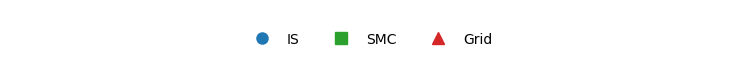

In [17]:
fig = comp.legend(ncol=3)
plt.show()

---
## 5  Comparing many posteriors — NoisyLine with varying noise

A more realistic use-case: we have one true model but five different IS posteriors
obtained with different proposal widths.  The boxplot should show how uncertainty
grows as the proposal degrades.

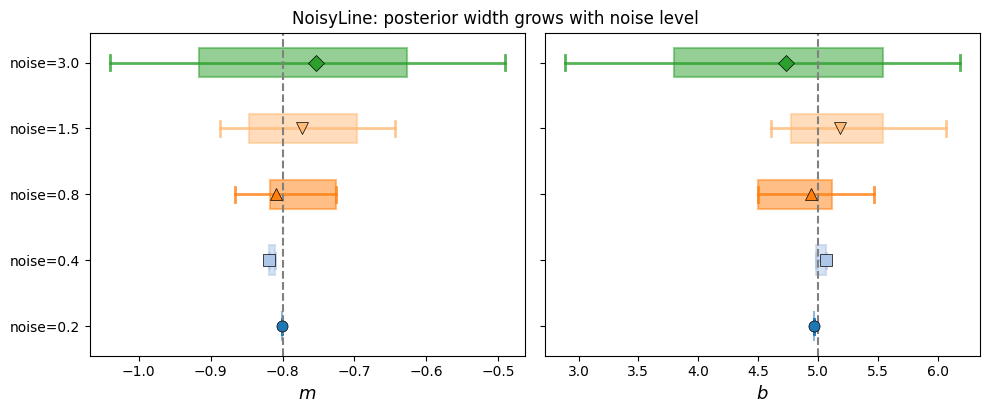

In [18]:
comp_nl = PosteriorComparison()

noise_levels = [0.2, 0.4, 0.8, 1.5, 3.0]
for noise in noise_levels:
    nl_var = NoisyLine(Nx=50, noise_sigma=noise)
    y_var  = nl_var.simulate(theta_true_nl)
    prior_var = UniformPrior([(-3, 3), (2, 8)])
    prop_var  = prior_var.sample(6000)
    s_var, w_var = importance_sampling(
        lambda t, _nl=nl_var, _y=y_var, _p=prior_var: _nl.log_prob(t, _y) + _p.log_prob(t),
        prop_var,
    )
    d = SampledDistribution(
        s_var, weights=w_var,
        true_values=theta_true_nl,
        labels=[r'm', r'b'],
    )
    comp_nl.add(d, label=f'noise={noise}')

fig = comp_nl.plot_boxplot()
plt.suptitle('NoisyLine: posterior width grows with noise level', y=1.02)
plt.show()

In [19]:
print(comp_nl.metrics_table().to_string(index=False))

    label  mahalanobis          z_1          z_2
noise=0.8 4.060000e-01 2.110000e-01 3.860000e-01
noise=3.0 4.320000e-01 2.760000e-01 4.080000e-01
noise=1.5 2.173000e+00 5.020000e-01 5.500000e-01
noise=0.2 1.035941e+14 1.025299e+14 1.447761e+13
noise=0.4          NaN 2.508000e+00 5.160000e-01


---
## 6  `plot_triangle` — corner / triangle plot

`plot_triangle` is a standalone function that accepts raw samples and forwards to
the chosen backend (`'corner'`, `'getdist'`, `'chainconsumer'`).  It is also
accessible directly from any `DistributionDiagnostic` via `.plot_triangle()`.

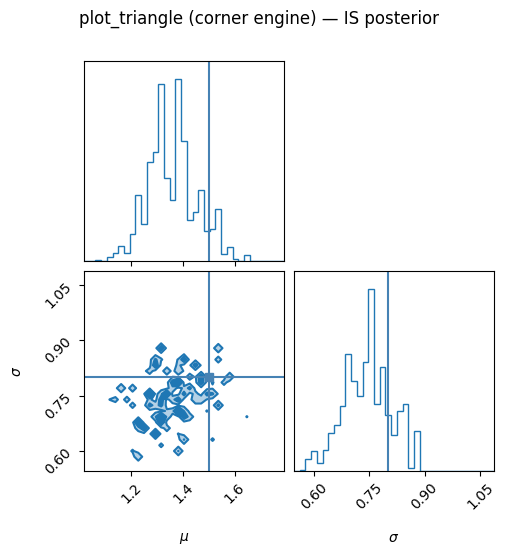

In [20]:
# Standalone function — corner backend
try:
    fig = plot_triangle(
        s_is,
        weights=w_is,
        labels=[r'\mu', r'\sigma'],
        true_values=theta_true_gs,
        engine='corner',
        bins=35,
        plot_datapoints=False,
        fill_contours=True,
        levels=(0.68, 0.95),
        color='C0',
    )
    plt.suptitle('plot_triangle (corner engine) — IS posterior', y=1.02)
    plt.show()
except ImportError:
    print('corner not installed — skipping')

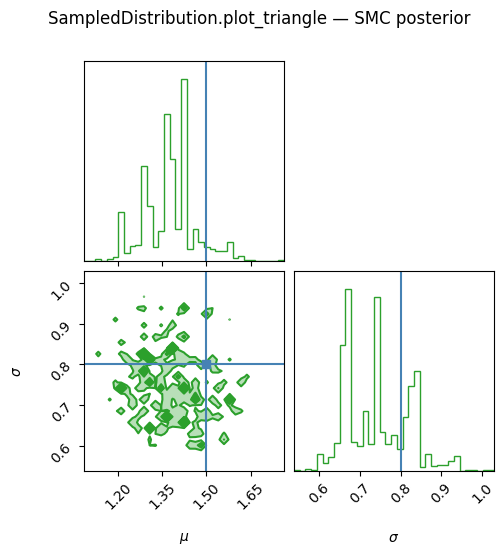

In [21]:
# Via the object method — same result
try:
    fig = dist_smc.plot_triangle(
        engine='corner',
        bins=35,
        plot_datapoints=False,
        fill_contours=True,
        levels=(0.68, 0.95),
        color='C2',
    )
    plt.suptitle('SampledDistribution.plot_triangle — SMC posterior', y=1.02)
    plt.show()
except ImportError:
    print('corner not installed — skipping')

Removed no burn in


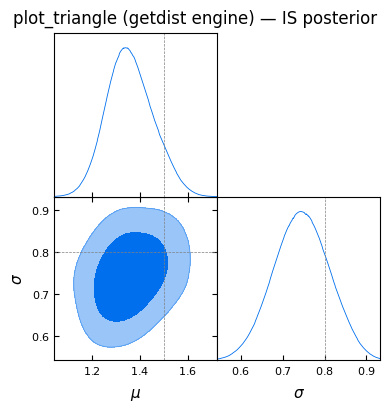

In [22]:
# getdist backend
try:
    g = plot_triangle(
        s_is,
        weights=w_is,
        labels=[r'\mu', r'\sigma'],
        true_values=theta_true_gs,
        engine='getdist',
    )
    plt.suptitle('plot_triangle (getdist engine) — IS posterior', y=1.02)
    plt.show()
except ImportError:
    print('getdist not installed — skipping')

---
## 7  `print_chain_stats` — standalone summary

`print_chain_stats` can be called with raw samples (it computes everything internally)
or with precomputed means, sigmas, and CIs.

In [23]:
# From raw weighted samples
print('── From samples ─────────────────────────────')
print_chain_stats(s_is, weights=w_is, labels=[r'\mu', r'\sigma'], levels=(68, 95))

── From samples ─────────────────────────────
Parameter summary
  \mu:  mean = 1.3584,  std = 0.0952
    68% CI: [1.2735, 1.4594]
    95% CI: [1.1850, 1.5386]
  \sigma:  mean = 0.7453,  std = 0.0648
    68% CI: [0.6728, 0.8134]
    95% CI: [0.6025, 0.8785]


In [24]:
# From precomputed statistics
means_gs, _, sigmas_gs, *_ = dist_is._weighted_stats()
cis_gs = dist_is.credible_intervals(levels=(68, 95))

print('── From precomputed means / sigmas / CIs ────')
print_chain_stats(means_gs, sigmas=sigmas_gs, cis=cis_gs,
                  labels=[r'\mu', r'\sigma'], levels=(68, 95))

── From precomputed means / sigmas / CIs ────
Parameter summary
  \mu:  mean = 1.3584,  std = 0.0956
    68% CI: [1.2735, 1.4594]
    95% CI: [1.1850, 1.5386]
  \sigma:  mean = 0.7453,  std = 0.0651
    68% CI: [0.6728, 0.8134]
    95% CI: [0.6025, 0.8785]


---
## 8  `score()` on `GriddedProbabilities`

The `score()` method integrates posterior mass inside a rectangular parameter region
defined by `true_ranges`.  It is used e.g. in the SDC3b challenge to rank inference methods.

Here we vary the size of the truth cube and observe how the score changes.

  half_width=0.05  score=0.0718
  half_width=0.10  score=0.2701
  half_width=0.20  score=0.7891
  half_width=0.40  score=0.9979
  half_width=0.60  score=1.0000


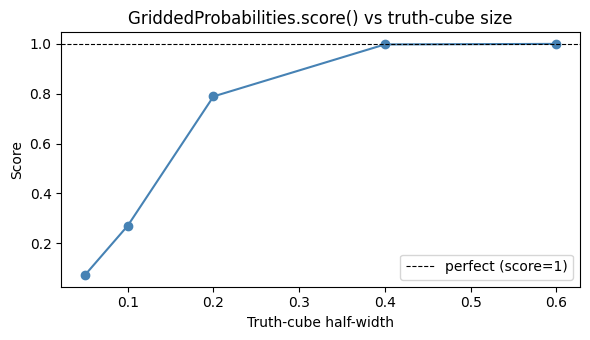

In [25]:
half_widths = [0.05, 0.1, 0.2, 0.4, 0.6]
scores = []

for hw in half_widths:
    d = GriddedProbabilities(
        prob_grid,
        coords=[mu_grid, sig_grid],
        true_values=theta_true_gs,
        true_ranges=[
            [theta_true_gs[0] - hw, theta_true_gs[0] + hw],
            [theta_true_gs[1] - hw, theta_true_gs[1] + hw],
        ],
    )
    scores.append(d.score())
    print(f'  half_width={hw:.2f}  score={d.score():.4f}')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(half_widths, scores, 'o-', c='steelblue')
ax.set(xlabel='Truth-cube half-width', ylabel='Score',
       title='GriddedProbabilities.score() vs truth-cube size')
ax.axhline(1.0, ls='--', c='k', lw=0.8, label='perfect (score=1)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 9  Mixing `SampledDistribution` and `GriddedProbabilities` in one comparison

`PosteriorComparison` works with any `DistributionDiagnostic` subclass, so you can
put grid-based and sample-based posteriors side by side directly.

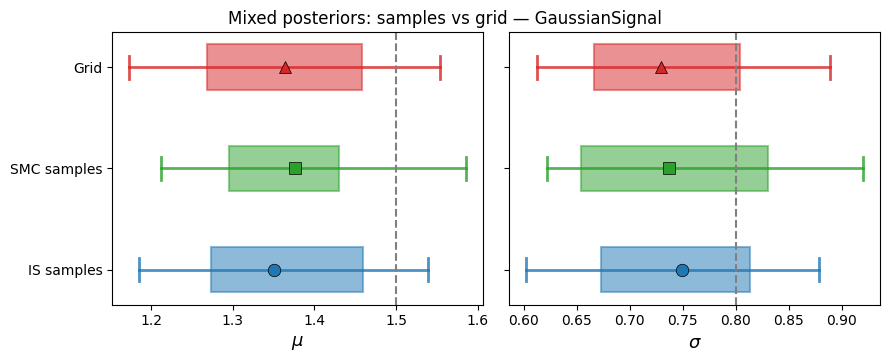


      label  mahalanobis   z_1   z_2  score
       Grid        1.517 1.282 0.813 0.9613
 IS samples        1.552 1.481 0.841    NaN
SMC samples        1.762 1.444 0.753    NaN


In [26]:
comp_mixed = PosteriorComparison()
comp_mixed.add(dist_is,   label='IS samples',  color='C0', marker='o', markersize=9)
comp_mixed.add(dist_smc,  label='SMC samples', color='C2', marker='s', markersize=9)
comp_mixed.add(dist_grid, label='Grid',        color='C3', marker='^', markersize=9)

fig = comp_mixed.plot_boxplot(levels=(68, 95), figsize=(9, 3.5))
plt.suptitle('Mixed posteriors: samples vs grid — GaussianSignal', y=1.02)
plt.show()

print()
print(comp_mixed.metrics_table().to_string(index=False))

---
## 10  Derived (pseudo) parameters — `add_derived`

`add_derived(func, label, true_value)` registers a parameter computed from
the original samples.  After that it appears everywhere: contour plots,
triangle plots, and metric methods.

A cosmology-style example: $S_8 = \sigma_8 \sqrt{\Omega_m / 0.3}$.
Here we use the two GaussianSignal parameters $(\mu, \sigma)$ and define
a pseudo-parameter $P = \mu \cdot \sqrt{|\sigma|}$ to mimic the idea.

In [ ]:
from psiphy.plotting.diagnostics import SampledDistribution

# Re-use the IS samples from Section 1
# true_values = [mu_true, sigma_true] = theta
dist_derived = SampledDistribution(
    s_is,
    weights=w_is,
    true_values=theta_true_gs,
    labels=[r'\mu', r'\sigma'],
)

# Register a derived parameter:  P = mu * sqrt(|sigma|)
true_P = float(theta_true_gs[0] * theta_true_gs[1] ** 0.5)
dist_derived.add_derived(
    lambda s: s[:, 0] * np.abs(s[:, 1]) ** 0.5,
    label=r'P',
    true_value=true_P,
)

print('Full labels  :', dist_derived._full_labels())
print('Full truths  :', dist_derived._full_true_values())

full_s, full_w = dist_derived.get_full_samples()
print('Sample shape :', full_s.shape)   # (N, 3)  — 2 original + 1 derived

### 10a  Credible intervals on the derived parameter

In [ ]:
cis = dist_derived.credible_intervals()        # original params only
cis_full = []
# credible_intervals() operates on get_samples(); for derived params, use
# the full sample column directly via plot_contour_1d or a manual CI:
from psiphy.plotting.diagnostics import SampledDistribution as SD
# Wrap derived column as its own 1-D posterior to get CI numbers:
derived_col = full_s[:, 2]
dist_P = SD(derived_col, weights=full_w, true_values=[true_P], labels=[r'P'])
ci_P = dist_P.credible_intervals()[0]
print(f'P  median={ci_P["median"]:.4f}'
      f'  68% [{ci_P["lo68"]:.4f}, {ci_P["hi68"]:.4f}]'
      f'  true={true_P:.4f}')

---
## 11  Single-panel contour plots

`plot_contour_1d(param)` and `plot_contour_2d(param1, param2)` draw
individual marginal panels using a KDE.

* `param` can be an **integer index** or a **label string** (including
  derived parameters).
* Both methods accept an `ax=` argument for embedding into existing figures.
* `PosteriorComparison` provides the same two methods to **overlay** all
  registered posteriors on a shared axes.

In [ ]:
# ── 11a  1-D marginal of an original parameter ────────────────────────────
fig = dist_derived.plot_contour_1d(param=0)       # mu
plt.title(r'1-D marginal: $\mu$')
plt.show()

In [ ]:
# ── 11b  1-D marginal of the derived parameter ────────────────────────────
fig = dist_derived.plot_contour_1d(param=r'P')
plt.title(r'1-D marginal: derived $P = \mu\,|\sigma|^{1/2}$')
plt.show()

In [ ]:
# ── 11c  2-D joint contour (original params) ──────────────────────────────
fig = dist_derived.plot_contour_2d(param1=0, param2=1)
plt.title(r'Joint: $\mu$ vs $\sigma$')
plt.show()

In [ ]:
# ── 11d  2-D joint contour (original vs derived) ─────────────────────────
fig = dist_derived.plot_contour_2d(param1=0, param2=r'P')
plt.title(r'Joint: $\mu$ vs derived $P$')
plt.show()

### 11e  Embedding into a multi-panel figure

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

dist_derived.plot_contour_1d(param=0, ax=axes[0], color='C0')
axes[0].set_title(r'$\mu$ marginal')

dist_derived.plot_contour_1d(param=r'P', ax=axes[1], color='C1')
axes[1].set_title(r'Derived $P$ marginal')

fig.tight_layout()
plt.show()

### 11f  `PosteriorComparison` overlay

In [ ]:
# Build a comparison: IS vs SMC, both with the derived parameter
dist_smc_d = SampledDistribution(
    s_smc, true_values=theta_true_gs, labels=[r'\mu', r'\sigma'],
)
dist_smc_d.add_derived(
    lambda s: s[:, 0] * np.abs(s[:, 1]) ** 0.5,
    label=r'P', true_value=true_P,
)

from psiphy.plotting.diagnostics import PosteriorComparison
comp_d = PosteriorComparison()
comp_d.add(dist_derived, label='IS',  color='C0')
comp_d.add(dist_smc_d,   label='SMC', color='C2')

# 1-D overlay
fig = comp_d.plot_contour_1d(param=r'P', fill=True, alpha=0.2)
plt.title(r'Overlay: derived $P$ — IS vs SMC')
plt.show()

In [ ]:
# 2-D overlay (filled=False keeps colours readable)
fig = comp_d.plot_contour_2d(param1=0, param2=r'P', filled=False)
plt.title(r'Overlay: $\mu$ vs $P$ — IS vs SMC')
plt.show()

---
## Summary

| What | How |
|---|---|
| Wrap IS/MCMC samples | `SampledDistribution(samples, weights, true_values, labels)` |
| Wrap a grid posterior | `GriddedProbabilities(grid, coords, true_values, labels, true_ranges)` |
| Metrics | `.z_scores()`, `.bias()`, `.pit()`, `.mahalanobis()`, `.kl_divergence(other)` |
| Per-parameter CIs | `.credible_intervals(levels=(68, 95))` |
| Print summary | `.print_stats()` or `print_chain_stats(samples)` |
| Triangle plot | `.plot_triangle(engine='corner')` or standalone `plot_triangle(...)` |
| Compare posteriors | `PosteriorComparison` → `.plot_boxplot()`, `.plot_forest()`, `.metrics_table()` |
| Posterior mass in truth cube | `GriddedProbabilities(..., true_ranges=...).score()` |

### Styling controls for `PosteriorComparison.add()`

| Argument | Default | Effect |
|---|---|---|
| `color` | `None` → tab20 cycle | Bar / box / line colour |
| `marker` | `True` → auto from marker cycle | `None` = no marker (matplotlib convention); any string = that symbol |
| `markersize` | `None` → method default (8) | Per-entry override |
| `linewidth` | `None` → method default (2) | Per-entry override |
| Single-panel KDE | `dist.plot_contour_1d(param)`, `dist.plot_contour_2d(p1, p2)` |
| Overlay contours | `comp.plot_contour_1d(param)`, `comp.plot_contour_2d(p1, p2)` |
| Derived parameters | `dist.add_derived(func, label, true_value)` |
